## Workflow

1. Load a manageable slice of the 60+ column dataset with proper encoding.
2. Coerce numeric telemetry, fill gaps, and profile the signals we will model.
3. Engineer safe lag/rolling features, weather interactions, and categorical one-hot vectors.
4. Train ridge (scaled linear) and Random Forest baselines with a chronological split.
5. Compare hold-out accuracy and visualize prediction fit to inform next iterations.

In [ ]:
import joblib
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

## 1. Data Loading

Read a limited row slice for rapid experimentation, ensuring timestamps stay sorted for time-aware modeling.

In [6]:
DATA_PATH = "../data/smart_city_energy_dataset.csv"
MAX_ROWS = 200_000

raw_df = (
    pd.read_csv(
        DATA_PATH,
        encoding="utf-8-sig",
        nrows=MAX_ROWS,
        parse_dates=["Timestamp"],
        infer_datetime_format=True,
    )
    .sort_values("Timestamp")
    .reset_index(drop=True)
)

print(f"Loaded rows: {len(raw_df):,}")
raw_df.head()

C:\Users\sekar\AppData\Local\Temp\ipykernel_15296\3504806347.py:5: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  pd.read_csv(


Loaded rows: 72,960


,Timestamp,Hour of Day,Day of Week,Is Weekend,Is Holiday,Season,Week of Year,Month,Historical Electricity Load (kW),Peak Load Indicator,...,Region/Zone ID,Latitude,Longitude,Altitude (m),Distance to Nearest Substation (km),Area Type,Electricity Load,Renewable Energy Load,Net Load,Curtailment Risk / Surplus Flag
0,2021-01-01 00:00:00,0,4,0,0,1,53,1,192.976646,0,...,ZoneA,35.009842,-105.518617,225.154387,0.599292,Suburban,209.578166,116.667293,92.910873,0
1,2021-01-01 00:30:00,0,4,0,0,2,53,1,709.417292,0,...,ZoneB,37.067136,-120.634755,556.305113,6.022215,Urban,711.329436,40.603240,670.726196,0
2,2021-01-01 01:00:00,1,4,0,0,2,53,1,441.323762,0,...,ZoneB,39.952764,-114.198386,432.500561,0.311498,Suburban,434.571941,45.235566,389.336376,0
3,2021-01-01 01:30:00,1,4,0,0,1,53,1,110.061053,0,...,ZoneA,44.179765,-78.504895,12.658897,2.689435,Urban,119.913430,216.133025,-96.219595,1
4,2021-01-01 02:00:00,2,4,0,0,2,53,1,741.130717,0,...,ZoneA,29.232799,-74.472891,477.191782,6.382530,Rural,747.746618,320.609219,427.137399,0


## 2. Numeric Coercion & Profiling

Convert telemetry columns to numeric, interpolate gaps, and quickly inspect the distributions that will drive the model.

In [7]:
df = raw_df.copy()
timestamp_col = "Timestamp"
df = df.dropna(subset=[timestamp_col]).sort_values(timestamp_col).reset_index(drop=True)

numeric_candidates = [
    "Electricity Load",
    "Renewable Energy Load",
    "Net Load",
    "Historical Electricity Load (kW)",
    "Peak Load Indicator",
    "Transformer Load Level",
    "Voltage Level (V)",
    "Current Level (A)",
    "Power Factor",
    "Demand Response Signal (Binary)",
    "Grid Frequency (Hz)",
    "Solar PV Output (kW)",
    "Wind Power Output (kW)",
    "Solar Panel Temperature (Â°C)",
    "Wind Speed (m/s)",
    "Wind Direction (degrees)",
    "Inverter Efficiency (%)",
    "Battery State of Charge (SOC) (%)",
    "Battery Discharge Rate (kW/h)",
    "Renewable Forecast Error",
    "Temperature (Â°C)",
    "Humidity (%)",
    "Solar Irradiance (W/mÂ²)",
    "Cloud Cover (%)",
    "Rainfall (mm)",
    "Snowfall (mm)",
    "Visibility (km)",
    "Atmospheric Pressure (hPa)",
    "Dew Point (Â°C)",
    "Smart Meter Reading per Building (kW)",
    "Building Occupancy Rate (%)",
    "Public Transit Operational Load (kW)",
    "EV Charging Station Load (kW)",
    "EV Charging Session Count",
    "Traffic Congestion Index",
    "Human Mobility Score",
    "Region Urban Density Index",
    "Time Since Last Peak (hours)",
    "Time Until Next Predicted Peak (hours)",
    "Latitude",
    "Longitude",
    "Altitude (m)",
    "Distance to Nearest Substation (km)"
]

available_numeric = [col for col in numeric_candidates if col in df.columns]

for col in available_numeric:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[available_numeric] = df[available_numeric].interpolate(limit_direction="both")
df[available_numeric] = df[available_numeric].fillna(method="bfill").fillna(method="ffill")

print(f"Numeric columns coerced: {len(available_numeric)}")
df[available_numeric].describe().T.head(12).round(2)

Numeric columns coerced: 39

C:\Users\sekar\AppData\Local\Temp\ipykernel_15296\1899765247.py:57: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[available_numeric] = df[available_numeric].fillna(method="bfill").fillna(method="ffill")


,count,mean,std,min,25%,50%,75%,max
Electricity Load,72960.0,451.13,261.92,-36.07,258.85,401.78,591.18,2626.81
Renewable Energy Load,72960.0,130.10,94.63,0.10,61.31,107.60,175.11,990.82
Net Load,72960.0,321.03,278.76,-808.97,127.24,280.21,474.38,2513.77
Historical Electricity Load (kW),72960.0,451.08,261.10,5.02,259.30,401.37,590.31,2583.38
Peak Load Indicator,72960.0,0.05,0.22,0.00,0.00,0.00,0.00,1.00
Transformer Load Level,72960.0,64.57,19.37,10.00,51.25,64.88,78.49,100.00
Voltage Level (V),72960.0,230.01,5.00,208.34,226.61,230.01,233.39,251.73
Current Level (A),72960.0,1.96,1.14,0.02,1.13,1.75,2.57,11.04
Power Factor,72960.0,0.80,0.12,0.18,0.73,0.82,0.89,1.00
Demand Response Signal (Binary),72960.0,0.05,0.22,0.00,0.00,0.00,0.00,1.00


## 3. Feature Engineering

Build calendar encodings, safe lag/rolling load history, renewable penetration, and categorical one-hot signals.

In [ ]:
LOAD_TARGET = "Electricity Load"
if LOAD_TARGET not in df.columns:
    raise ValueError("Target column 'Electricity Load' missing from dataset.")

# Keep the base dataframe sorted and ready for time-based feature creation.
df_fe = df.sort_values(timestamp_col).reset_index(drop=True)
df_fe["hour"] = df_fe[timestamp_col].dt.hour
df_fe["dayofweek"] = df_fe[timestamp_col].dt.dayofweek
df_fe["month"] = df_fe[timestamp_col].dt.month
df_fe["weekofyear"] = df_fe[timestamp_col].dt.isocalendar().week.astype(int)
df_fe["sin_hour"] = np.sin(2 * np.pi * df_fe["hour"] / 24)
df_fe["cos_hour"] = np.cos(2 * np.pi * df_fe["hour"] / 24)
df_fe["sin_dayofyear"] = np.sin(2 * np.pi * df_fe[timestamp_col].dt.dayofyear / 365.25)
df_fe["cos_dayofyear"] = np.cos(2 * np.pi * df_fe[timestamp_col].dt.dayofyear / 365.25)

if {"Temperature (Â°C)", "Humidity (%)"}.issubset(df_fe.columns):
    df_fe["temp_humidity_interaction"] = df_fe["Temperature (Â°C)"] * df_fe["Humidity (%)"]

if {"Renewable Energy Load", LOAD_TARGET}.issubset(df_fe.columns):
    df_fe["renewable_penetration"] = (
        (df_fe["Renewable Energy Load"] / df_fe[LOAD_TARGET].replace(0, np.nan)).clip(0, 3).fillna(0)
    )

LAG_STEPS = [1, 2, 3, 6, 12, 24]
for lag in LAG_STEPS:
    df_fe[f"load_lag_{lag}h"] = df_fe[LOAD_TARGET].shift(lag)

ROLL_WINDOWS = [6, 12, 24, 48]
for window in ROLL_WINDOWS:
    shifted = df_fe[LOAD_TARGET].shift(1)
    df_fe[f"load_roll_mean_{window}h"] = shifted.rolling(window=window).mean()
    df_fe[f"load_roll_std_{window}h"] = shifted.rolling(window=window).std()

categorical_candidates = [
    "Weather Condition",
    "Area Type",
    "Load Sector Type",
    "Region/Zone ID",
    "Substation ID / Region ID",
    "Season",
    "Curtailment Risk / Surplus Flag",
]
categorical_available = [col for col in categorical_candidates if col in df_fe.columns]

encoded_cols = []
if categorical_available:
    df_fe[categorical_available] = df_fe[categorical_available].fillna("Unknown").astype(str)
    cat_encoded = pd.get_dummies(
        df_fe[categorical_available],
        prefix=[col.replace(" ", "_") for col in categorical_available],
        drop_first=True,
    )
    df_fe = pd.concat([df_fe, cat_encoded], axis=1)
    encoded_cols = list(cat_encoded.columns)

base_driver_cols = [
    "Temperature (Â°C)",
    "Humidity (%)",
    "Solar Irradiance (W/mÂ²)",
    "Cloud Cover (%)",
    "Rainfall (mm)",
    "Wind Speed (m/s)",
    "Wind Direction (degrees)",
    "Solar PV Output (kW)",
    "Wind Power Output (kW)",
    "EV Charging Station Load (kW)",
    "EV Charging Session Count",
    "Public Transit Operational Load (kW)",
    "Traffic Congestion Index",
    "Human Mobility Score",
    "Battery State of Charge (SOC) (%)",
    "Battery Discharge Rate (kW/h)",
    "Demand Response Signal (Binary)",
    "Peak Load Indicator",
    "Grid Frequency (Hz)",
    "Time Since Last Peak (hours)",
    "Time Until Next Predicted Peak (hours)",
    "Smart Meter Reading per Building (kW)",
    "Building Occupancy Rate (%)",
]
available_driver_cols = [col for col in base_driver_cols if col in df_fe.columns]

engineered_cols = [
    "hour",
    "dayofweek",
    "month",
    "weekofyear",
    "sin_hour",
    "cos_hour",
    "sin_dayofyear",
    "cos_dayofyear",
    "temp_humidity_interaction",
    "renewable_penetration",
]
engineered_cols += [col for col in df_fe.columns if col.startswith("load_lag_") or col.startswith("load_roll_")]
available_engineered_cols = [col for col in engineered_cols if col in df_fe.columns]

feature_columns = available_driver_cols + available_engineered_cols + encoded_cols
feature_columns = [col for col in feature_columns if col in df_fe.columns]

TARGETS_TO_MODEL = [
    "Electricity Load",
    "Battery State of Charge (SOC) (%)",
    "EV Charging Station Load (kW)",
    "EV Charging Session Count",
    "Public Transit Operational Load (kW)",
]
available_targets = [t for t in TARGETS_TO_MODEL if t in df_fe.columns]

feature_store = df_fe[[timestamp_col] + feature_columns + available_targets].copy()
print(f"Samples with engineered features: {len(feature_store):,}")
print(f"Feature count: {len(feature_columns):,}")
print(f"Targets available for modeling: {available_targets}")

Samples after feature engineering: 72,912
Feature count: 61


## 4. Modeling

Run both Ridge and Random Forest baselines for every operational target (load, battery SOC, EV charging metrics, transit load) using the shared engineered feature matrix and chronological splits.

In [ ]:
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

performance_rows = []
load_diag = None

TARGET_SLUGS = {
    "Electricity Load": "electricity_load",
    "Battery State of Charge (SOC) (%)": "battery_soc",
    "EV Charging Station Load (kW)": "ev_load",
    "EV Charging Session Count": "ev_sessions",
    "Public Transit Operational Load (kW)": "transit_load",
}

for target in TARGETS_TO_MODEL:
    if target not in feature_store.columns:
        print(f"Skipping {target}: column not in dataset")
        continue

    target_df = feature_store[[timestamp_col, target] + feature_columns].dropna()
    if len(target_df) < 2000:
        print(f"Skipping {target}: insufficient samples ({len(target_df)})")
        continue

    split_idx = int(len(target_df) * 0.8)
    train_df = target_df.iloc[:split_idx].copy()
    test_df = target_df.iloc[split_idx:].copy()

    X_train = train_df[feature_columns]
    y_train = train_df[target].values
    X_test = test_df[feature_columns]
    y_test = test_df[target].values

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    ridge_model = Ridge(alpha=1.0)
    ridge_model.fit(X_train_scaled, y_train)

    rf_model = RandomForestRegressor(
        n_estimators=400,
        max_depth=18,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42,
    )
    rf_model.fit(X_train, y_train)

    preds_ridge = ridge_model.predict(X_test_scaled)
    preds_rf = rf_model.predict(X_test)

    def summarize_metrics(y_true, preds, label):
        mae = mean_absolute_error(y_true, preds)
        rmse = np.sqrt(mean_squared_error(y_true, preds))
        r2 = r2_score(y_true, preds)
        return {"Target": target, "Model": label, "MAE": mae, "RMSE": rmse, "R2": r2}

    performance_rows.extend(
        [
            summarize_metrics(y_test, preds_ridge, "Ridge"),
            summarize_metrics(y_test, preds_rf, "Random Forest"),
        ]
    )

    slug = TARGET_SLUGS.get(target, target.lower().replace(" ", "_"))
    ridge_artifact = {
        "model": ridge_model,
        "scaler": scaler,
        "features": feature_columns,
        "target": target,
    }
    rf_artifact = {
        "model": rf_model,
        "features": feature_columns,
        "target": target,
    }

    ridge_path = MODELS_DIR / f"advanced_ridge_{slug}.pkl"
    rf_path = MODELS_DIR / f"advanced_rf_{slug}.pkl"

    joblib.dump(ridge_artifact, ridge_path)
    joblib.dump(rf_artifact, rf_path)

    print(f"Saved Ridge model for {target} -> {ridge_path}")
    print(f"Saved Random Forest model for {target} -> {rf_path}")

    if target == LOAD_TARGET:
        load_diag = {
            "timestamps": test_df[timestamp_col].values,
            "y_test": y_test,
            "preds_ridge": preds_ridge,
            "preds_rf": preds_rf,
        }

if not performance_rows:
    raise RuntimeError("No models were trained. Ensure target columns exist with enough samples.")

perf_df = pd.DataFrame(performance_rows)
perf_df.round(3)

,Model,MAE,RMSE,R2
0,Ridge,123.592,157.324,0.639
1,Random Forest,13.257,32.547,0.985


## 5. Prediction Diagnostics

Plot the final window of predictions versus actuals and inspect residual spread for the non-linear model.

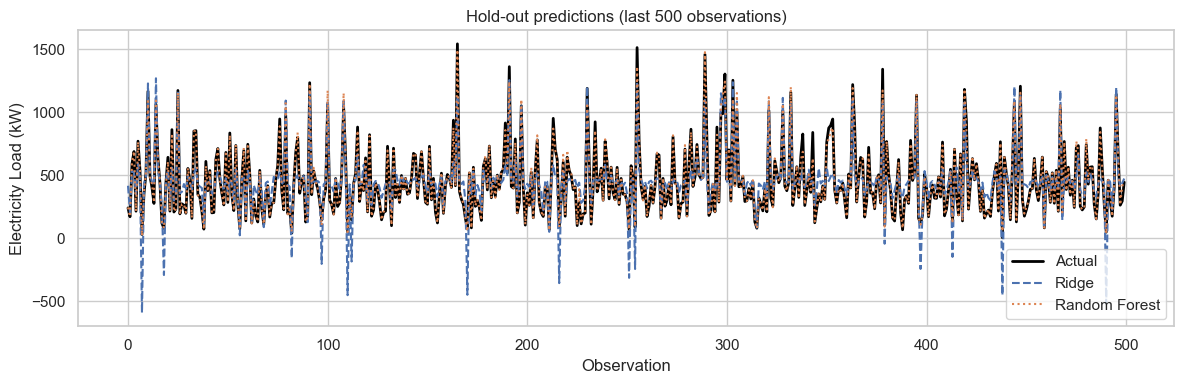

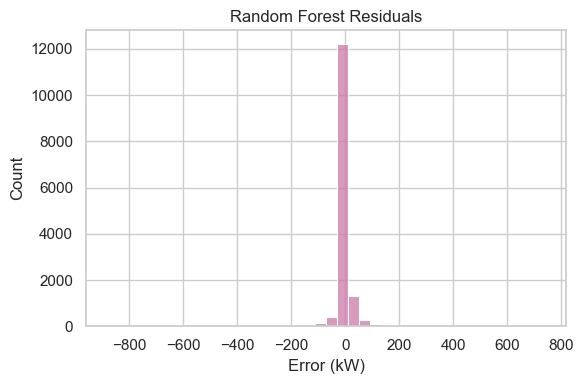

In [ ]:
if load_diag is None:
    raise ValueError("Electricity Load diagnostics unavailable — ensure that target was modeled above.")

window = min(500, len(load_diag["y_test"]))
comparison = pd.DataFrame(
    {
        "Timestamp": load_diag["timestamps"][-window:],
        "Actual": load_diag["y_test"][-window:],
        "Ridge": load_diag["preds_ridge"][-window:],
        "RandomForest": load_diag["preds_rf"][-window:],
    }
).reset_index(drop=True)

plt.figure(figsize=(12, 4))
plt.plot(comparison.index, comparison["Actual"], label="Actual", color="black", linewidth=2)
plt.plot(comparison.index, comparison["Ridge"], label="Ridge", linestyle="--")
plt.plot(comparison.index, comparison["RandomForest"], label="Random Forest", linestyle=":")
plt.title("Electricity Load hold-out predictions (last window)")
plt.xlabel("Observation")
plt.ylabel("Electricity Load (kW)")
plt.legend()
plt.tight_layout()
plt.show()

residuals_rf = load_diag["y_test"] - load_diag["preds_rf"]
plt.figure(figsize=(6, 4))
sns.histplot(residuals_rf, bins=40, color="#CC79A7")
plt.title("Electricity Load Random Forest Residuals")
plt.xlabel("Error (kW)")
plt.tight_layout()
plt.show()

## Next Steps

- Hyper-tune tree depths and regularization using `TimeSeriesSplit` or walk-forward validation.
- Introduce gradient boosting or sequence models (TFT, N-BEATS) to ingest the richer lagged context.
- Layer in probabilistic targets (prediction intervals) for grid risk management scenarios.
- Push engineered feature set back into Streamlit for scenario exploration once accuracy is validated.